In [1]:
print("Hello World")

Hello World


In [ ]:
# ===============================
# 1. IMPORT LIBRARIES (NO SKLEARN)
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 2. LINEAR REGRESSION CLASS
# ===============================
# class LinearRegression:

#     def __init__(self, learning_rate=0.01, no_of_iterations=1500):
#         self.learning_rate = learning_rate
#         self.no_of_iterations = no_of_iterations

#     def fit(self, X, Y):

#         self.m, self.n = X.shape
#         self.w = np.zeros(self.n)
#         self.b = 0

#         self.X = X
#         self.Y = Y
#         self.costs = []

#         for _ in range(self.no_of_iterations):
#             self.update_weights()

#     def update_weights(self):

#         Y_pred = self.predict(self.X)

#         dw = -(2 / self.m) * self.X.T.dot(self.Y - Y_pred)
#         db = -(2 / self.m) * np.sum(self.Y - Y_pred)

#         self.w -= self.learning_rate * dw
#         self.b -= self.learning_rate * db

#         cost = np.mean((self.Y - Y_pred) ** 2)
#         self.costs.append(cost)

#     def predict(self, X):
#         return X.dot(self.w) + self.b


In [3]:
df = pd.read_csv('files/co2.csv')

print(df.head())
print(df.shape)
print(df.isnull().sum())


    Make       Model Vehicle Class  Engine Size(L)  Cylinders Transmission  \
0  ACURA         ILX       COMPACT             2.0          4          AS5   
1  ACURA         ILX       COMPACT             2.4          4           M6   
2  ACURA  ILX HYBRID       COMPACT             1.5          4          AV7   
3  ACURA     MDX 4WD   SUV - SMALL             3.5          6          AS6   
4  ACURA     RDX AWD   SUV - SMALL             3.5          6          AS6   

  Fuel Type  Fuel Consumption City (L/100 km)  \
0         Z                               9.9   
1         Z                              11.2   
2         Z                               6.0   
3         Z                              12.7   
4         Z                              12.1   

   Fuel Consumption Hwy (L/100 km)  Fuel Consumption Comb (L/100 km)  \
0                              6.7                               8.5   
1                              7.7                               9.6   
2                   

In [4]:
num_df = df.select_dtypes(include=['int64', 'float64'])


In [5]:
corr_matrix = num_df.corr()
print(corr_matrix)


                                  Engine Size(L)  Cylinders  \
Engine Size(L)                          1.000000   0.927653   
Cylinders                               0.927653   1.000000   
Fuel Consumption City (L/100 km)        0.831379   0.800702   
Fuel Consumption Hwy (L/100 km)         0.761526   0.715252   
Fuel Consumption Comb (L/100 km)        0.817060   0.780534   
Fuel Consumption Comb (mpg)            -0.757854  -0.719321   
CO2 Emissions(g/km)                     0.851145   0.832644   

                                  Fuel Consumption City (L/100 km)  \
Engine Size(L)                                            0.831379   
Cylinders                                                 0.800702   
Fuel Consumption City (L/100 km)                          1.000000   
Fuel Consumption Hwy (L/100 km)                           0.948180   
Fuel Consumption Comb (L/100 km)                          0.993810   
Fuel Consumption Comb (mpg)                              -0.927059   
CO2 E

In [6]:
target = 'CO2 Emissions(g/km)'

target_corr = corr_matrix[target].sort_values(ascending=False)
print(target_corr)





CO2 Emissions(g/km)                 1.000000
Fuel Consumption City (L/100 km)    0.919592
Fuel Consumption Comb (L/100 km)    0.918052
Fuel Consumption Hwy (L/100 km)     0.883536
Engine Size(L)                      0.851145
Cylinders                           0.832644
Fuel Consumption Comb (mpg)        -0.907426
Name: CO2 Emissions(g/km), dtype: float64


In [7]:
exclude_features = [
    'Fuel Consumption City (L/100 km)',
    'Fuel Consumption Hwy (L/100 km)',
    'Fuel Consumption Comb (mpg)'
]


In [9]:
final_features = [
    col for col in num_df.columns
    if col not in exclude_features and col != target
]

print("\nFinal features used for modeling:")
print(final_features)



Final features used for modeling:
['Engine Size(L)', 'Cylinders', 'Fuel Consumption Comb (L/100 km)']


In [10]:
print("\nCorrelation matrix of final selected features:")
print(df[final_features + [target]].corr())



Correlation matrix of final selected features:
                                  Engine Size(L)  Cylinders  \
Engine Size(L)                          1.000000   0.927653   
Cylinders                               0.927653   1.000000   
Fuel Consumption Comb (L/100 km)        0.817060   0.780534   
CO2 Emissions(g/km)                     0.851145   0.832644   

                                  Fuel Consumption Comb (L/100 km)  \
Engine Size(L)                                            0.817060   
Cylinders                                                 0.780534   
Fuel Consumption Comb (L/100 km)                          1.000000   
CO2 Emissions(g/km)                                       0.918052   

                                  CO2 Emissions(g/km)  
Engine Size(L)                               0.851145  
Cylinders                                    0.832644  
Fuel Consumption Comb (L/100 km)             0.918052  
CO2 Emissions(g/km)                          1.000000  


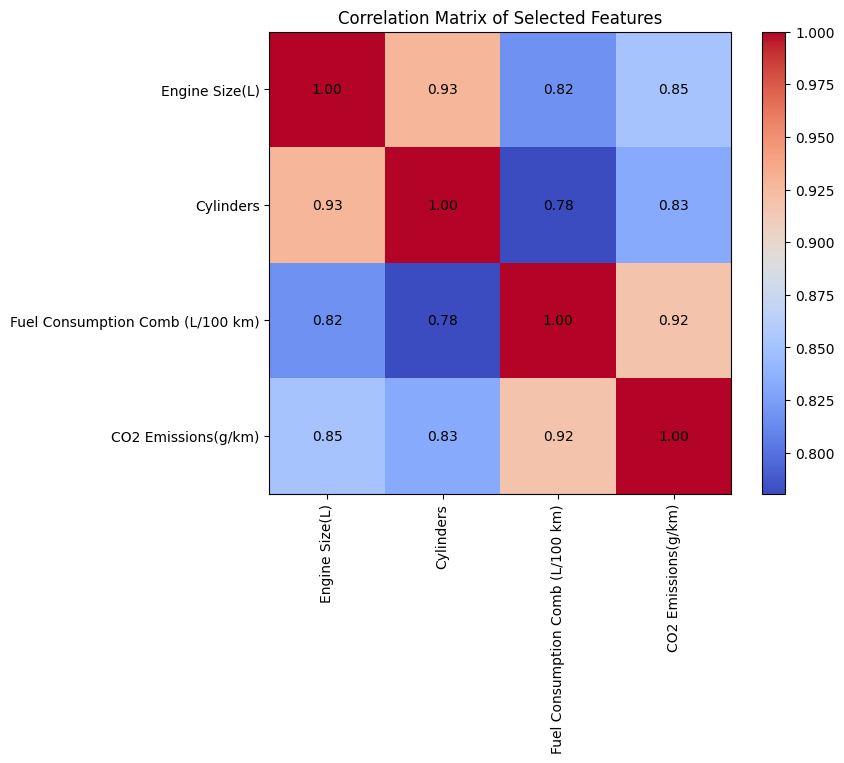

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df[final_features + [target]].corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Matrix of Selected Features")
plt.show()


In [12]:
X = df[final_features].values
Y = df[target].values



In [13]:
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)

X = (X - X_mean) / X_std


In [14]:
X = df[final_features].values
y = df[target].values

# Feature scaling (IMPORTANT for gradient descent)
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)

X = (X - X_mean) / X_std


In [15]:
class LinearRegressionGD:

    def __init__(self, learning_rate=0.01, iterations=2000):
        self.lr = learning_rate
        self.iterations = iterations
        self.costs = []

    def fit(self, X, y):
        self.m, self.n = X.shape
        self.w = np.zeros(self.n)
        self.b = 0

        for _ in range(self.iterations):
            y_pred = self.predict(X)

            dw = (2/self.m) * X.T.dot(y_pred - y)
            db = (2/self.m) * np.sum(y_pred - y)

            self.w -= self.lr * dw
            self.b -= self.lr * db

            cost = np.mean((y - y_pred) ** 2)
            self.costs.append(cost)

    def predict(self, X):
        return X.dot(self.w) + self.b


In [16]:
model = LinearRegressionGD(learning_rate=0.01, iterations=2000)
model.fit(X, y)

print("Weights:", model.w)
print("Bias:", model.b)


Weights: [ 7.73233392 11.60417749 38.33570114]
Bias: 250.58469871360796


In [17]:
y_pred = model.predict(X)

# RMSE
rmse = np.sqrt(np.mean((y - y_pred) ** 2))

# R-squared
ss_total = np.sum((y - np.mean(y)) ** 2)
ss_res = np.sum((y - y_pred) ** 2)
r2 = 1 - ss_res / ss_total

print("\nRMSE:", rmse)
print("R-squared:", r2)



RMSE: 20.33605229629364
R-squared: 0.8791929886490766


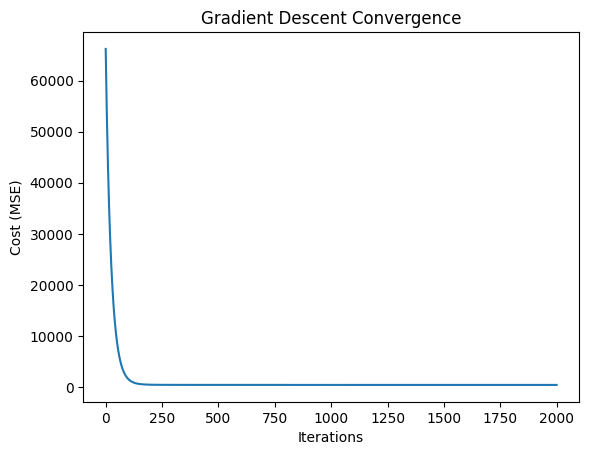

In [18]:
plt.plot(model.costs)
plt.xlabel("Iterations")
plt.ylabel("Cost (MSE)")
plt.title("Gradient Descent Convergence")
plt.show()


In [19]:
# plt.scatter(y, y_pred)
# plt.xlabel("Actual CO2 Emissions")
# plt.ylabel("Predicted CO2 Emissions")
# plt.title("Actual vs Predicted CO2 Emissions")
# plt.show()


In [20]:
# np.random.seed(42)

# indices = np.arange(len(X))
# np.random.shuffle(indices)

# split = int(0.7 * len(X))

# train_idx = indices[:split]
# test_idx = indices[split:]

# X_train = X[train_idx]
# X_test = X[test_idx]

# Y_train = Y[train_idx]
# Y_test = Y[test_idx]


In [21]:
# model = LinearRegression(learning_rate=0.01, no_of_iterations=1500)
# model.fit(X_train, Y_train)

# print("Learned weights:", model.w)
# print("Learned bias:", model.b)


In [22]:
# Y_pred = model.predict(X_test)

# # RMSE
# rmse = np.sqrt(np.mean((Y_test - Y_pred) ** 2))

# # R-squared
# ss_total = np.sum((Y_test - np.mean(Y_test)) ** 2)
# ss_res = np.sum((Y_test - Y_pred) ** 2)
# r2 = 1 - ss_res / ss_total

# print("RMSE:", rmse)
# print("R-squared:", r2)


In [23]:
# plt.plot(model.costs)
# plt.xlabel("Iterations")
# plt.ylabel("Cost (MSE)")
# plt.title("Gradient Descent Convergence (CO2 Dataset)")
# plt.show()
